Mounted at /content/drive

  BRAIN CT SCAN — TUMOR vs. NORMAL CLASSIFICATION

  Loading dataset from: /content/drive/MyDrive/CT scan Images (limited)
  Classes found: ['Healthy', 'Tumor']
  [Healthy] — 100 images found  (label=0)
  [Tumor] — 101 images found  (label=1)

  Total images loaded : 201
  Image array shape   : (201, 128, 128, 3)


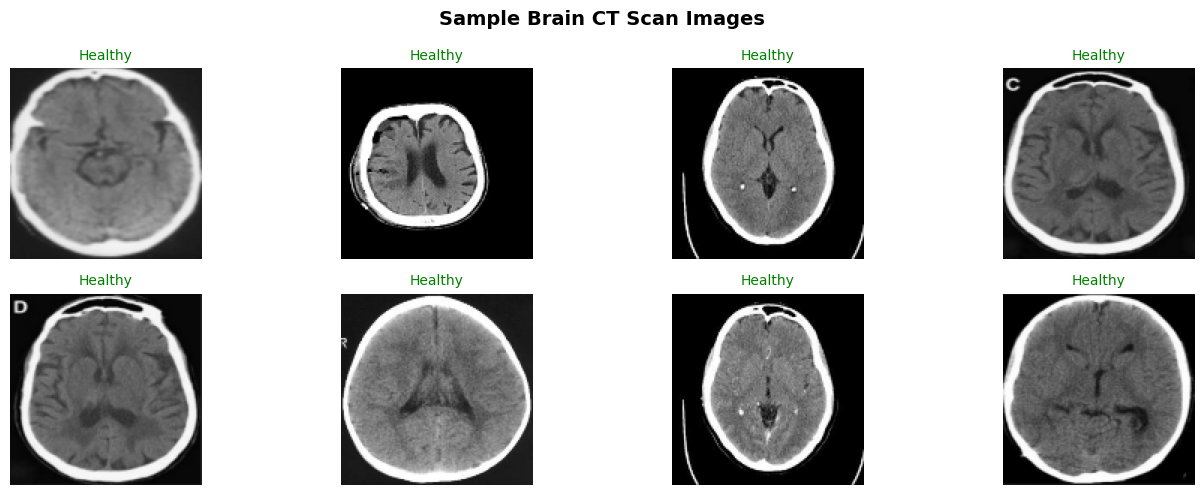

  Saved: sample_images.png

  Training samples : 160
  Testing  samples : 41

  CLASSICAL MACHINE LEARNING CLASSIFIERS

  Training SVM (RBF kernel) ...
  SVM (RBF kernel) Accuracy : 87.80%
  SVM (RBF kernel) AUC      : 0.9357

              precision    recall  f1-score   support

      Normal       0.89      0.85      0.87        20
       Tumor       0.86      0.90      0.88        21

    accuracy                           0.88        41
   macro avg       0.88      0.88      0.88        41
weighted avg       0.88      0.88      0.88        41


  Training K-Nearest Neighbors ...
  K-Nearest Neighbors Accuracy : 63.41%
  K-Nearest Neighbors AUC      : 0.7917

              precision    recall  f1-score   support

      Normal       0.58      0.90      0.71        20
       Tumor       0.80      0.38      0.52        21

    accuracy                           0.63        41
   macro avg       0.69      0.64      0.61        41
weighted avg       0.69      0.63      0.61        41


 

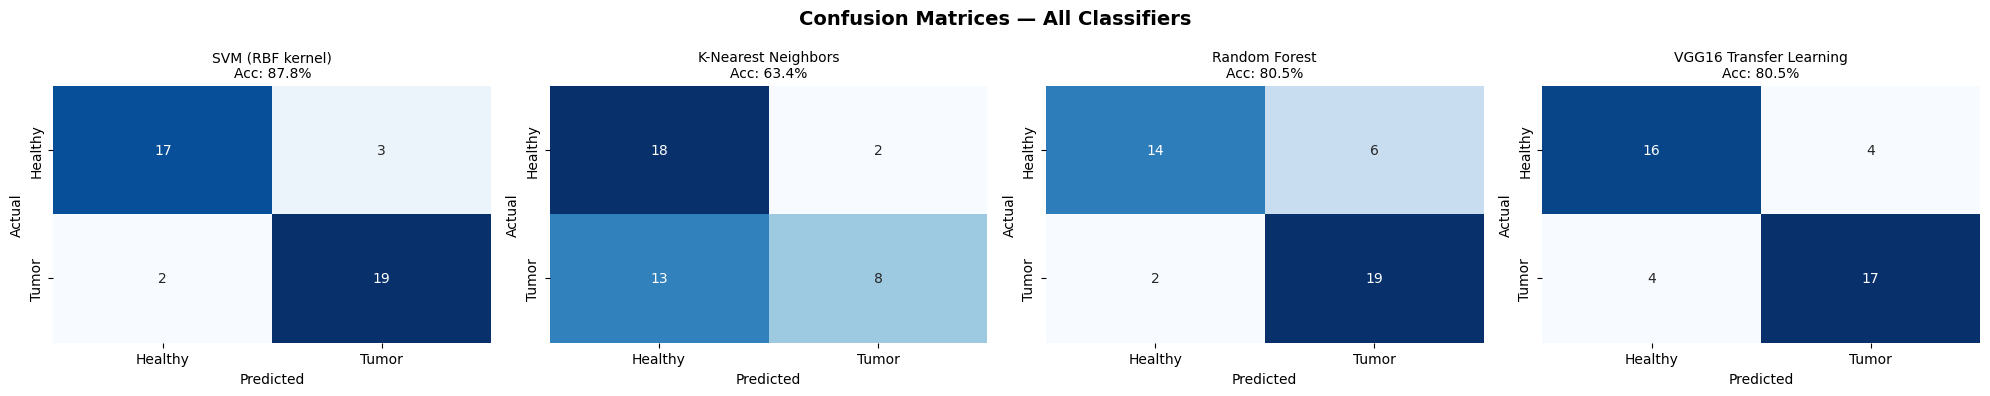

  Saved: confusion_matrices.png


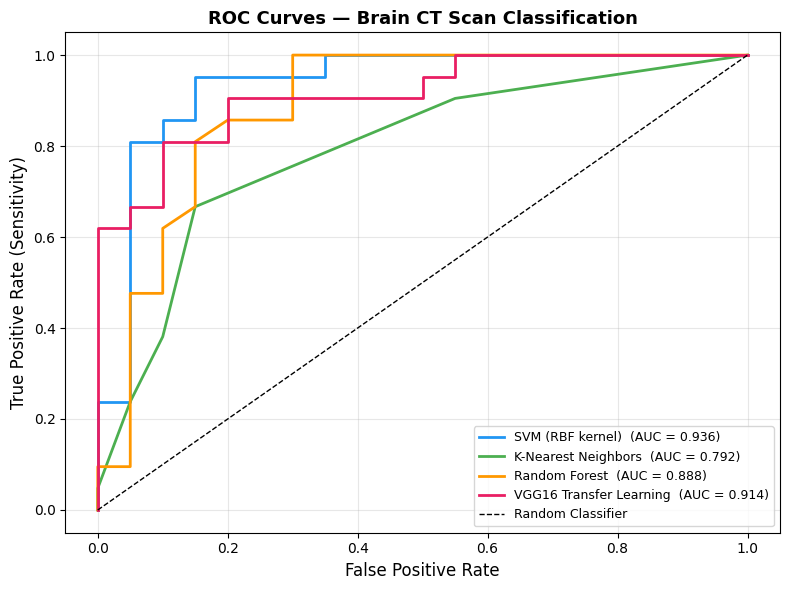

  Saved: roc_curves.png


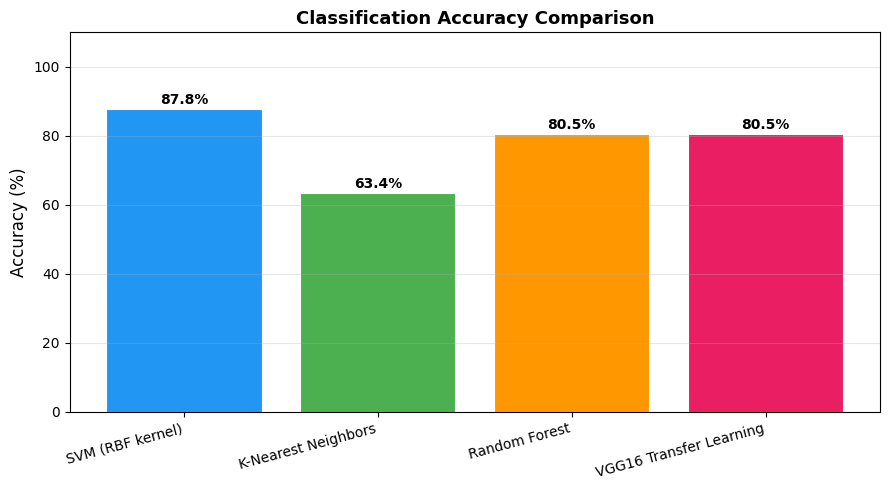

  Saved: accuracy_comparison.png


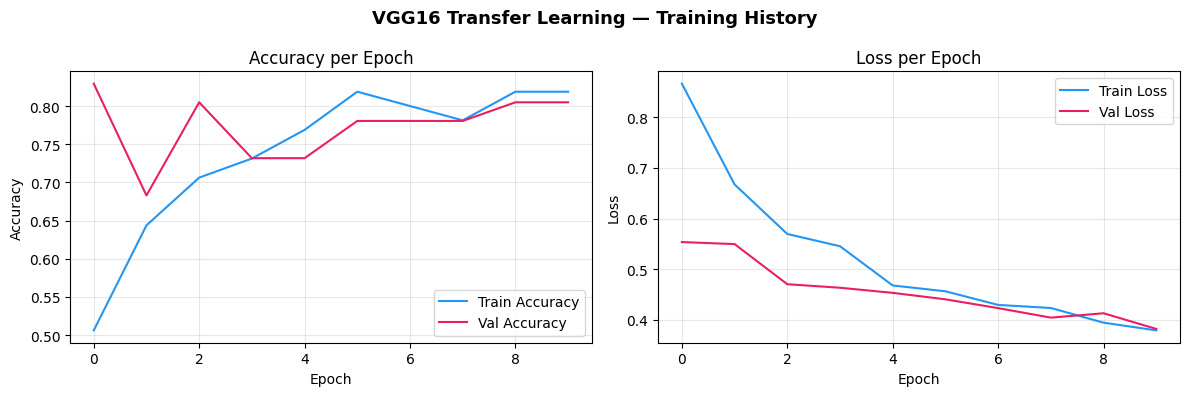

  Saved: vgg16_training_history.png

  All done! Check the generated .png files in your working directory.



In [ ]:
"""
=============================================================================
BRAIN CT SCAN IMAGE CLASSIFICATION
=============================================================================
Course   : Image Processing & Computer Vision
Supervisor: Dr. Wasswa William (PhD)
Task     : Binary Classification — Tumor vs. Normal

Four Techniques Implemented:
  1. Support Vector Machine (SVM)
  2. K-Nearest Neighbors (KNN)
  3. Random Forest
  4. Transfer Learning (VGG16 — fine-tuned)

=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — Edit these paths/settings before running
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH  = '/content/drive/MyDrive/CT scan Images (limited)'          # Path to your dataset folder
IMAGE_SIZE    = (128, 128)         # Resize all images to this (width, height)
TEST_SPLIT    = 0.2                # 20% of data used for testing
RANDOM_SEED   = 42                 # For reproducibility
VGG_EPOCHS    = 10                 # Training epochs for VGG16
VGG_BATCH     = 16                 # Batch size for VGG16 training

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — LOAD AND PREPROCESS IMAGES
# ─────────────────────────────────────────────────────────────────────────────

def load_dataset(dataset_path, image_size):
    """
    Reads images from two class folders (tumor / normal).
    Returns:
        images : numpy array of shape (N, H, W, 3)  — RGB images
        labels : numpy array of shape (N,)           — 0=normal, 1=tumor
        class_names : list of folder names found
    """
    images, labels = [], []
    class_names    = sorted(os.listdir(dataset_path))   # e.g. ['normal', 'tumor']

    print(f"\n{'='*60}")
    print(f"  Loading dataset from: {dataset_path}")
    print(f"  Classes found: {class_names}")
    print(f"{'='*60}")

    label_map = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_folder = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_folder):
            continue

        file_list = [
            f for f in os.listdir(class_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))
        ]

        print(f"  [{class_name}] — {len(file_list)} images found  (label={label_map[class_name]})")

        for fname in file_list:
            img_path = os.path.join(class_folder, fname)
            img = cv2.imread(img_path)
            if img is None:
                continue                                   # skip unreadable files
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # convert BGR → RGB
            img = cv2.resize(img, image_size)             # resize to fixed size
            img = img.astype(np.float32) / 255.0          # normalise to [0, 1]
            images.append(img)
            labels.append(label_map[class_name])

    images = np.array(images)
    labels = np.array(labels)
    print(f"\n  Total images loaded : {len(images)}")
    print(f"  Image array shape   : {images.shape}")
    return images, labels, class_names


def flatten_images(images):
    """
    Converts 3-D images to 1-D feature vectors for classical ML models.
    Shape: (N, H, W, 3) → (N, H*W*3)
    """
    n_samples = images.shape[0]
    return images.reshape(n_samples, -1)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — CLASSICAL ML HELPERS (SVM, KNN, Random Forest)
# ─────────────────────────────────────────────────────────────────────────────

def train_evaluate_classical(name, model, X_train, X_test, y_train, y_test):
    """
    Trains a classical ML model, evaluates it, and returns a results dict.
    """
    print(f"\n  Training {name} ...")
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    acc     = accuracy_score(y_test, y_pred)
    report  = classification_report(y_test, y_pred, target_names=["Normal", "Tumor"])
    cm      = confusion_matrix(y_test, y_pred)

    # ROC-AUC (only for models with predict_proba or decision_function)
    try:
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)
            # normalise decision function to [0,1]
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-8)
        auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
    except Exception:
        auc, fpr, tpr = None, None, None

    print(f"  {name} Accuracy : {acc*100:.2f}%")
    print(f"  {name} AUC      : {auc:.4f}" if auc else f"  {name} AUC: N/A")
    print(f"\n{report}")

    return {
        "name"   : name,
        "model"  : model,
        "acc"    : acc,
        "auc"    : auc,
        "cm"     : cm,
        "fpr"    : fpr,
        "tpr"    : tpr,
        "report" : report,
    }


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — TRANSFER LEARNING WITH VGG16
# ─────────────────────────────────────────────────────────────────────────────

def build_vgg16_model(input_shape, num_classes=2):
    """
    Loads VGG16 pre-trained on ImageNet, freezes its convolutional layers,
    and attaches a custom classification head for our binary task.
    """
    base_model = VGG16(
        weights     = "imagenet",   # use ImageNet weights
        include_top = False,        # remove original classifier head
        input_shape = input_shape
    )
    # Freeze all convolutional layers — we only train the new head
    for layer in base_model.layers:
        layer.trainable = False

    # Custom classification head
    x = Flatten()(base_model.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)                          # prevents overfitting
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer = Adam(learning_rate=1e-4),
        loss      = "categorical_crossentropy",
        metrics   = ["accuracy"]
    )
    return model


def train_vgg16(X_train, X_test, y_train, y_test, epochs, batch_size):
    """
    Trains VGG16-based transfer learning model and evaluates it.
    """
    print("\n  Training VGG16 Transfer Learning model ...")

    # VGG16 expects images of at least 32×32 — reshape if needed
    input_shape = X_train.shape[1:]   # (H, W, 3)

    # One-hot encode labels for categorical cross-entropy
    y_train_cat = to_categorical(y_train, num_classes=2)
    y_test_cat  = to_categorical(y_test,  num_classes=2)

    # Light data augmentation to improve generalisation
    datagen = ImageDataGenerator(
        rotation_range    = 15,
        width_shift_range = 0.1,
        height_shift_range= 0.1,
        horizontal_flip   = True,
    )
    datagen.fit(X_train)

    model   = build_vgg16_model(input_shape)
    history = model.fit(
        datagen.flow(X_train, y_train_cat, batch_size=batch_size),
        validation_data = (X_test, y_test_cat),
        epochs          = epochs,
        verbose         = 1,
    )

    # Evaluation
    y_prob  = model.predict(X_test)[:, 1]
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cm      = confusion_matrix(y_test, y_pred)
    report  = classification_report(y_test, y_pred, target_names=["Normal", "Tumor"])

    print(f"  VGG16 Accuracy : {acc*100:.2f}%")
    print(f"  VGG16 AUC      : {auc:.4f}")
    print(f"\n{report}")

    return {
        "name"    : "VGG16 Transfer Learning",
        "model"   : model,
        "acc"     : acc,
        "auc"     : auc,
        "cm"      : cm,
        "fpr"     : fpr,
        "tpr"     : tpr,
        "report"  : report,
        "history" : history,
    }


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

def plot_sample_images(images, labels, class_names, n=8):
    """Plots a grid of sample CT scan images with their class labels."""
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 5))
    fig.suptitle("Sample Brain CT Scan Images", fontsize=14, fontweight="bold")
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i])
        ax.set_title(class_names[labels[i]], fontsize=10,
                     color="red" if labels[i] == 1 else "green")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: sample_images.png")


def plot_confusion_matrices(results, class_names):
    """Plots confusion matrices side by side for all four classifiers."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    fig.suptitle("Confusion Matrices — All Classifiers", fontsize=14, fontweight="bold")

    for ax, res in zip(axes, results):
        sns.heatmap(
            res["cm"], annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, cbar=False
        )
        ax.set_title(f"{res['name']}\nAcc: {res['acc']*100:.1f}%", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: confusion_matrices.png")


def plot_roc_curves(results):
    """Plots ROC curves for all four classifiers on a single chart."""
    plt.figure(figsize=(8, 6))
    colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

    for res, color in zip(results, colors):
        if res["fpr"] is not None:
            label = f"{res['name']}  (AUC = {res['auc']:.3f})"
            plt.plot(res["fpr"], res["tpr"], color=color, lw=2, label=label)

    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
    plt.title("ROC Curves — Brain CT Scan Classification", fontsize=13, fontweight="bold")
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: roc_curves.png")


def plot_accuracy_bar(results):
    """Plots a bar chart comparing accuracy of all classifiers."""
    names  = [r["name"] for r in results]
    accs   = [r["acc"] * 100 for r in results]
    colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(names, accs, color=colors, edgecolor="white", linewidth=0.8)
    for bar, acc in zip(bars, accs):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{acc:.1f}%", ha="center", va="bottom", fontweight="bold"
        )
    plt.ylim(0, 110)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.title("Classification Accuracy Comparison", fontsize=13, fontweight="bold")
    plt.xticks(rotation=15, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: accuracy_comparison.png")


def plot_vgg16_training(vgg_result):
    """Plots VGG16 training & validation accuracy/loss curves."""
    history = vgg_result.get("history")
    if history is None:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("VGG16 Transfer Learning — Training History", fontsize=13, fontweight="bold")

    # Accuracy
    ax1.plot(history.history["accuracy"],     label="Train Accuracy", color="#2196F3")
    ax1.plot(history.history["val_accuracy"], label="Val Accuracy",   color="#E91E63")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.set_title("Accuracy per Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(history.history["loss"],     label="Train Loss", color="#2196F3")
    ax2.plot(history.history["val_loss"], label="Val Loss",   color="#E91E63")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.set_title("Loss per Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("vgg16_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Saved: vgg16_training_history.png")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

def print_summary_table(results):
    """Prints a neat comparison table in the console."""
    print(f"\n{'='*60}")
    print(f"  FINAL RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"  {'Classifier':<30} {'Accuracy':>10} {'AUC':>10}")
    print(f"  {'-'*50}")
    for r in results:
        auc_str = f"{r['auc']:.4f}" if r["auc"] else "  N/A  "
        print(f"  {r['name']:<30} {r['acc']*100:>9.2f}%  {auc_str:>10}")
    print(f"{'='*60}\n")

    # Best classifier
    best = max(results, key=lambda x: x["acc"])
    print(f"  ✔  Best classifier: {best['name']}  ({best['acc']*100:.2f}% accuracy)\n")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def main():
    print("\n" + "="*60)
    print("  BRAIN CT SCAN — TUMOR vs. NORMAL CLASSIFICATION")
    print("="*60)

    # ── 1. Load dataset ──────────────────────────────────────────
    images, labels, class_names = load_dataset(DATASET_PATH, IMAGE_SIZE)

    # ── 2. Preview some images ───────────────────────────────────
    plot_sample_images(images, labels, class_names)

    # ── 3. Train/Test split ──────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels,
        test_size    = TEST_SPLIT,
        random_state = RANDOM_SEED,
        stratify     = labels      # keeps class balance in both splits
    )
    print(f"\n  Training samples : {len(X_train)}")
    print(f"  Testing  samples : {len(X_test)}")

    # ── 4. Flatten images for classical ML ──────────────────────
    X_train_flat = flatten_images(X_train)
    X_test_flat  = flatten_images(X_test)

    # Scale features to zero mean, unit variance (important for SVM & KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)

    # ── 5. Classical classifiers ─────────────────────────────────
    print(f"\n{'='*60}")
    print("  CLASSICAL MACHINE LEARNING CLASSIFIERS")
    print(f"{'='*60}")

    svm_result = train_evaluate_classical(
        "SVM (RBF kernel)",
        SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
            random_state=RANDOM_SEED),
        X_train_scaled, X_test_scaled, y_train, y_test
    )

    knn_result = train_evaluate_classical(
        "K-Nearest Neighbors",
        KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
        X_train_scaled, X_test_scaled, y_train, y_test
    )

    rf_result = train_evaluate_classical(
        "Random Forest",
        RandomForestClassifier(n_estimators=200, max_depth=None,
                               random_state=RANDOM_SEED, n_jobs=-1),
        X_train_scaled, X_test_scaled, y_train, y_test
    )

    # ── 6. VGG16 Transfer Learning ───────────────────────────────
    print(f"\n{'='*60}")
    print("  DEEP LEARNING — VGG16 TRANSFER LEARNING")
    print(f"{'='*60}")

    vgg_result = train_vgg16(
        X_train, X_test, y_train, y_test,
        epochs=VGG_EPOCHS, batch_size=VGG_BATCH
    )

    # ── 7. Collect all results ───────────────────────────────────
    all_results = [svm_result, knn_result, rf_result, vgg_result]

    # ── 8. Summary & Plots ───────────────────────────────────────
    print_summary_table(all_results)
    plot_confusion_matrices(all_results, class_names)
    plot_roc_curves(all_results)
    plot_accuracy_bar(all_results)
    plot_vgg16_training(vgg_result)

    print("\n  All done! Check the generated .png files in your working directory.\n")


# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    main()
